In [57]:

# MACHINE LEARNING PROJECT: Customer Choice Prediction for Tanzanian Market

# Group Members:
# Date: February 2026
# Course: Machine Learning Test 2

# Introduction
# This project aims to predict customer satisfaction based on product attributes and customer demographics. 
# The model helps businesses understand which factors drive customer choices in the Tanzanian market, 
# enabling better product development and marketing strategies.

# 1. Import Libraries and Load Dataset

# %%
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

In [4]:
# %%
# Load the three CSV files

# 1. Complete dataset (all features)
df_complete = pd.read_csv('tanzanian_customer_choice_dataset.csv')

print("\n" + "=" * 60)
print("COMPLETE DATASET - First 5 rows")
print("=" * 60)
df_complete.head()


COMPLETE DATASET - First 5 rows


,transaction_id,customer_id,purchase_date,product_category,product_model,brand,brand_origin,brand_tier,product_status,price_tzs,...,brand_loyalty,price_sensitivity,quality_sensitivity,cultural_preference_strength,price_per_unit,is_weekend_purchase,purchase_month,purchase_year,customer_satisfaction,is_repeat_customer
0,TRX_000001,CUST_02385,2025-02-16,Mobile Phone,Infinix Note 11,Infinix,China,Mid-Range,New,306441,...,0.21,0.72,0.75,0.5,306441,1,2,2025,0.78,1
1,TRX_000002,CUST_01998,2025-01-11,Mobile Phone,Infinix Hot 11,Infinix,China,Mid-Range,New,563571,...,0.52,0.71,0.60,0.7,563571,1,1,2025,0.71,1
2,TRX_000003,CUST_04667,2025-02-15,Mobile Phone,Itel A36,Itel,China,Budget,New,151954,...,0.08,0.75,0.60,0.5,151954,1,2,2025,0.66,1
3,TRX_000004,CUST_00995,2025-02-27,Mobile Phone,Nokia G10,Nokia,Finland,Mid-Range,New,400685,...,0.26,0.60,0.60,0.5,400685,0,2,2025,0.71,1
4,TRX_000005,CUST_02656,2024-12-31,Mobile Phone,Tecno Spark 9,Tecno,China,Mid-Range,New,405017,...,0.32,0.77,0.74,0.7,405017,0,12,2024,0.72,1


In [5]:
# 2. Feature matrix (ready for modeling)
df_features = pd.read_csv('tanzanian_customer_choice_features.csv')
print("\n" + "=" * 60)
print("FEATURE MATRIX - First 5 rows")
print("=" * 60)
df_features.head()


FEATURE MATRIX - First 5 rows


,customer_id,age,gender,region,religion,ethnic_group,education,income_bracket,mobile_money,tech_savvy_score,...,purchase_month,price_factor,quality_factor,cultural_compatibility,social_influence,status_factor,origin_factor,utility_score,customer_satisfaction,is_repeat_customer
0,CUST_02385,40,Female,Dar es Salaam,Muslim,Others,Bachelor,"<200,000",Tigo Pesa,3,...,2,0.448,0.555,0.9,0.708,1.0,1.0,0.739,0.78,1
1,CUST_01998,36,Female,Dodoma,Muslim,Others,Secondary,"200,000-500,000",Tigo Pesa,4,...,1,0.000,0.420,0.9,0.819,1.0,1.0,0.462,0.71,1
2,CUST_04667,27,Female,Arusha,Muslim,Others,Secondary,"200,000-500,000",M-Pesa,3,...,2,0.240,0.294,0.9,0.902,1.0,1.0,0.355,0.66,1
3,CUST_00995,15,Female,Tanga,Muslim,Others,Primary,"500,001-1,000,000",Halopesa,3,...,2,0.399,0.390,0.9,0.503,1.0,1.0,0.539,0.71,1
4,CUST_02656,40,Male,Mbeya,Muslim,Others,Secondary,"<200,000",Airtel Money,3,...,12,0.220,0.496,0.9,0.799,1.0,1.0,0.598,0.72,1


In [6]:
# 3. Simple version (for beginners/quick analysis)
df_simple = pd.read_csv('tanzanian_customer_choice_simple.csv')
print("\n" + "=" * 60)
print("SIMPLE DATASET - First 5 rows")
print("=" * 60)
df_simple.head()


SIMPLE DATASET - First 5 rows


,customer_id,age,gender,region,religion,income_bracket,brand,brand_tier,product_status,price_tzs,quality_score,cultural_compatibility,utility_score,customer_satisfaction,is_repeat_customer
0,CUST_02385,40,Female,Dar es Salaam,Muslim,"<200,000",Infinix,Mid-Range,New,306441,7.4,0.9,0.739,0.78,1
1,CUST_01998,36,Female,Dodoma,Muslim,"200,000-500,000",Infinix,Mid-Range,New,563571,7.0,0.9,0.462,0.71,1
2,CUST_04667,27,Female,Arusha,Muslim,"200,000-500,000",Itel,Budget,New,151954,4.9,0.9,0.355,0.66,1
3,CUST_00995,15,Female,Tanga,Muslim,"500,001-1,000,000",Nokia,Mid-Range,New,400685,6.5,0.9,0.539,0.71,1
4,CUST_02656,40,Male,Mbeya,Muslim,"<200,000",Tecno,Mid-Range,New,405017,6.7,0.9,0.598,0.72,1


In [7]:
# %%
# Dataset information
print("\n" + "=" * 60)
print("DATASET INFORMATION - Complete Dataset")
print("=" * 60)
print(df_complete.info())


DATASET INFORMATION - Complete Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                10000 non-null  object 
 1   customer_id                   10000 non-null  object 
 2   purchase_date                 10000 non-null  object 
 3   product_category              10000 non-null  object 
 4   product_model                 10000 non-null  object 
 5   brand                         10000 non-null  object 
 6   brand_origin                  10000 non-null  object 
 7   brand_tier                    10000 non-null  object 
 8   product_status                10000 non-null  object 
 9   price_tzs                     10000 non-null  int64  
 10  quantity                      10000 non-null  int64  
 11  total_amount_tzs              10000 non-null  int64  
 12  quality_score        

In [8]:
# %%
# Statistical summary
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY - Numerical Columns")
print("=" * 60)
print(df_complete.describe())


STATISTICAL SUMMARY - Numerical Columns
          price_tzs      quantity  total_amount_tzs  quality_score  \
count  1.000000e+04  10000.000000      1.000000e+04   10000.000000   
mean   8.039475e+05      1.008400      8.053781e+05       7.512450   
std    6.559927e+05      0.118873      6.549729e+05       1.342238   
min    4.103800e+04      1.000000      4.103800e+04       3.000000   
25%    3.445225e+05      1.000000      3.473155e+05       6.500000   
50%    5.026240e+05      1.000000      5.039855e+05       7.400000   
75%    1.183314e+06      1.000000      1.183314e+06       8.600000   
max    2.499377e+06      3.000000      2.499377e+06      10.000000   

       price_factor  quality_factor  brand_preference  cultural_compatibility  \
count  10000.000000    10000.000000      10000.000000            10000.000000   
mean       0.289067        0.451633          0.719336                0.964460   
std        0.262731        0.155901          0.115044                0.047866   
min 

In [9]:
# %%
# Check for missing values
print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing_values = df_complete.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No missing values found!")


MISSING VALUES CHECK
No missing values found!


In [48]:
# %%
df = df_complete  # Using complete dataset for this project

print("\n Using COMPLETE dataset for model training")
print(f"   Final dataset shape: {df.shape}")


 Using COMPLETE dataset for model training
   Final dataset shape: (10000, 45)


In [12]:
# %% [markdown]
# ## 2. Data Overview and Exploration

# %%
# Basic statistics of target variable (customer_satisfaction)
print("\n" + "=" * 60)
print("TARGET VARIABLE: Customer Satisfaction")
print("=" * 60)
print(f"Mean: {df['customer_satisfaction'].mean():.3f}")
print(f"Median: {df['customer_satisfaction'].median():.3f}")
print(f"Std Dev: {df['customer_satisfaction'].std():.3f}")
print(f"Min: {df['customer_satisfaction'].min():.3f}")
print(f"Max: {df['customer_satisfaction'].max():.3f}")


TARGET VARIABLE: Customer Satisfaction
Mean: 0.690
Median: 0.710
Std Dev: 0.090
Min: 0.380
Max: 0.870


In [13]:
# %%
# Distribution of categorical variables
print("\n" + "=" * 60)
print("CATEGORICAL VARIABLES DISTRIBUTION")
print("=" * 60)

categorical_cols = ['region', 'gender', 'religion', 'brand', 'brand_tier', 'product_status']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(df[col].value_counts().head())


CATEGORICAL VARIABLES DISTRIBUTION

REGION:
Dar es Salaam    2467
Mwanza           1438
Arusha           1272
Dodoma           1196
Mbeya            1034
Name: region, dtype: int64

GENDER:
Female    5135
Male      4865
Name: gender, dtype: int64

RELIGION:
Christian    6085
Muslim       3554
Other         361
Name: religion, dtype: int64

BRAND:
Tecno      1487
Apple      1237
Samsung    1227
Huawei     1220
Infinix    1214
Name: brand, dtype: int64

BRAND_TIER:
Mid-Range    5690
Premium      3684
Budget        626
Name: brand_tier, dtype: int64

PRODUCT_STATUS:
New     8775
Used    1225
Name: product_status, dtype: int64


In [47]:
# %% [markdown]
# 3. Data Preprocessing

# Select relevant features for prediction
# Target: customer_satisfaction (0-1 scale)
# Features: factors that influence customer choice

feature_columns = [
    # Customer demographics
    'age', 'tech_savvy_score', 'brand_loyalty', 'price_sensitivity', 
    'quality_sensitivity', 'cultural_preference_strength',
    
    # Product attributes
    'price_tzs', 'quality_score',
    
    # Choice factors (these are the key drivers)
    'price_factor', 'quality_factor', 'brand_preference',
    'cultural_compatibility', 'social_influence', 'status_factor', 'origin_factor'
]

target_column = 'customer_satisfaction'

# Create feature matrix and target vector
X = df[feature_columns].copy()
y = df[target_column].copy()

print(f"\n Features selected: {len(feature_columns)}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


 Features selected: 15
Features shape: (10000, 15)
Target shape: (10000,)


In [46]:
# %%
# Handle categorical variables
# Encode region
label_encoder_region = LabelEncoder()
df['region_encoded'] = label_encoder_region.fit_transform(df['region'])

# Encode gender
label_encoder_gender = LabelEncoder()
df['gender_encoded'] = label_encoder_gender.fit_transform(df['gender'])

# Encode religion
label_encoder_religion = LabelEncoder()
df['religion_encoded'] = label_encoder_religion.fit_transform(df['religion'])

# Add encoded categorical features
X['region_encoded'] = df['region_encoded']
X['gender_encoded'] = df['gender_encoded']
X['religion_encoded'] = df['religion_encoded']

print(f"\n Added encoded categorical features")
print(f"Final features shape: {X.shape}")
print(f"\nFeatures now include: {list(X.columns)}")


 Added encoded categorical features
Final features shape: (10000, 18)

Features now include: ['age', 'tech_savvy_score', 'brand_loyalty', 'price_sensitivity', 'quality_sensitivity', 'cultural_preference_strength', 'price_tzs', 'quality_score', 'price_factor', 'quality_factor', 'brand_preference', 'cultural_compatibility', 'social_influence', 'status_factor', 'origin_factor', 'region_encoded', 'gender_encoded', 'religion_encoded']


In [45]:
# %%
# Check for any missing values in our selected features
print("\nMissing values in features:")
print(X.isnull().sum())

# If any missing values, fill with mean
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())
    print(" Filled missing values with mean")


Missing values in features:
age                             0
tech_savvy_score                0
brand_loyalty                   0
price_sensitivity               0
quality_sensitivity             0
cultural_preference_strength    0
price_tzs                       0
quality_score                   0
price_factor                    0
quality_factor                  0
brand_preference                0
cultural_compatibility          0
social_influence                0
status_factor                   0
origin_factor                   0
region_encoded                  0
gender_encoded                  0
religion_encoded                0
dtype: int64


In [44]:
# %%
# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(" Features scaled")
print(f"Scaled features shape: {X_scaled.shape}")

 Features scaled
Scaled features shape: (10000, 18)


In [18]:
# %% [markdown]
# ## 4. Split Data into Training and Testing Sets

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training set size: (8000, 18)
Testing set size: (2000, 18)
Training samples: 8000
Testing samples: 2000


In [43]:
# %% [markdown]
# 5. Train Linear Regression Model

print("\n" + "=" * 60)
print("TRAINING LINEAR REGRESSION MODEL")
print("=" * 60)

# Create and train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

# Evaluate
lr_train_mse = mean_squared_error(y_train, lr_train_pred)
lr_test_mse = mean_squared_error(y_test, lr_test_pred)
lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)
lr_train_mae = mean_absolute_error(y_train, lr_train_pred)
lr_test_mae = mean_absolute_error(y_test, lr_test_pred)

print("\n LINEAR REGRESSION PERFORMANCE:")
print(f"Training MSE: {lr_train_mse:.4f}")
print(f"Testing MSE: {lr_test_mse:.4f}")
print(f"Training R²: {lr_train_r2:.4f}")
print(f"Testing R²: {lr_test_r2:.4f}")
print(f"Training MAE: {lr_train_mae:.4f}")
print(f"Testing MAE: {lr_test_mae:.4f}")


TRAINING LINEAR REGRESSION MODEL

 LINEAR REGRESSION PERFORMANCE:
Training MSE: 0.0000
Testing MSE: 0.0000
Training R²: 0.9990
Testing R²: 0.9990
Training MAE: 0.0025
Testing MAE: 0.0025


In [23]:
# Cross-validation
lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='r2')
print(f"\nCross-validation R² scores: {lr_cv_scores}")
print(f"Mean CV R²: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std() * 2:.4f})")


Cross-validation R² scores: [0.99902284 0.99902408 0.99893959 0.99886968 0.99899773]
Mean CV R²: 0.9990 (+/- 0.0001)


In [42]:
# %% [markdown]
# 6. Train Decision Tree Model

print("\n" + "=" * 60)
print("TRAINING DECISION TREE MODEL")
print("=" * 60)

# Create and train model
dt_model = DecisionTreeRegressor(
    max_depth=10,           # Limit depth to prevent overfitting
    min_samples_split=20,   # Minimum samples to split a node
    min_samples_leaf=10,    # Minimum samples in a leaf
    random_state=42
)
dt_model.fit(X_train, y_train)

# Make predictions
dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

# Evaluate
dt_train_mse = mean_squared_error(y_train, dt_train_pred)
dt_test_mse = mean_squared_error(y_test, dt_test_pred)
dt_train_r2 = r2_score(y_train, dt_train_pred)
dt_test_r2 = r2_score(y_test, dt_test_pred)
dt_train_mae = mean_absolute_error(y_train, dt_train_pred)
dt_test_mae = mean_absolute_error(y_test, dt_test_pred)

print("\n DECISION TREE PERFORMANCE:")
print(f"Training MSE: {dt_train_mse:.4f}")
print(f"Testing MSE: {dt_test_mse:.4f}")
print(f"Training R²: {dt_train_r2:.4f}")
print(f"Testing R²: {dt_test_r2:.4f}")
print(f"Training MAE: {dt_train_mae:.4f}")
print(f"Testing MAE: {dt_test_mae:.4f}")


TRAINING DECISION TREE MODEL

 DECISION TREE PERFORMANCE:
Training MSE: 0.0000
Testing MSE: 0.0001
Training R²: 0.9951
Testing R²: 0.9933
Training MAE: 0.0043
Testing MAE: 0.0052


In [29]:
# Cross-validation
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='r2')
print(f"\nCross-validation R² scores: {dt_cv_scores}")
print(f"Mean CV R²: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std() * 2:.4f})")


Cross-validation R² scores: [0.99293742 0.992734   0.9910891  0.99122102 0.9909882 ]
Mean CV R²: 0.9918 (+/- 0.0017)


In [30]:
# %% [markdown]
# 7. Compare Model Performance

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'Training MSE': [lr_train_mse, dt_train_mse],
    'Testing MSE': [lr_test_mse, dt_test_mse],
    'Training R²': [lr_train_r2, dt_train_r2],
    'Testing R²': [lr_test_r2, dt_test_r2],
    'Training MAE': [lr_train_mae, dt_train_mae],
    'Testing MAE': [lr_test_mae, dt_test_mae]
})

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(comparison.to_string(index=False))


MODEL COMPARISON
            Model  Training MSE  Testing MSE  Training R²  Testing R²  Training MAE  Testing MAE
Linear Regression      0.000008     0.000008     0.998979    0.998995      0.002497     0.002498
    Decision Tree      0.000040     0.000055     0.995059    0.993297      0.004271     0.005151


In [41]:
# Determine best model
if dt_test_r2 > lr_test_r2:
    best_model = dt_model
    best_model_name = "Decision Tree"
    best_r2 = dt_test_r2
    best_mae = dt_test_mae
else:
    best_model = lr_model
    best_model_name = "Linear Regression"
    best_r2 = lr_test_r2
    best_mae = lr_test_mae

print(f"\n BEST MODEL: {best_model_name}")
print(f"   Testing R²: {best_r2:.4f}")
print(f"   Testing MAE: {best_mae:.4f}")


 BEST MODEL: Linear Regression
   Testing R²: 0.9990
   Testing MAE: 0.0025


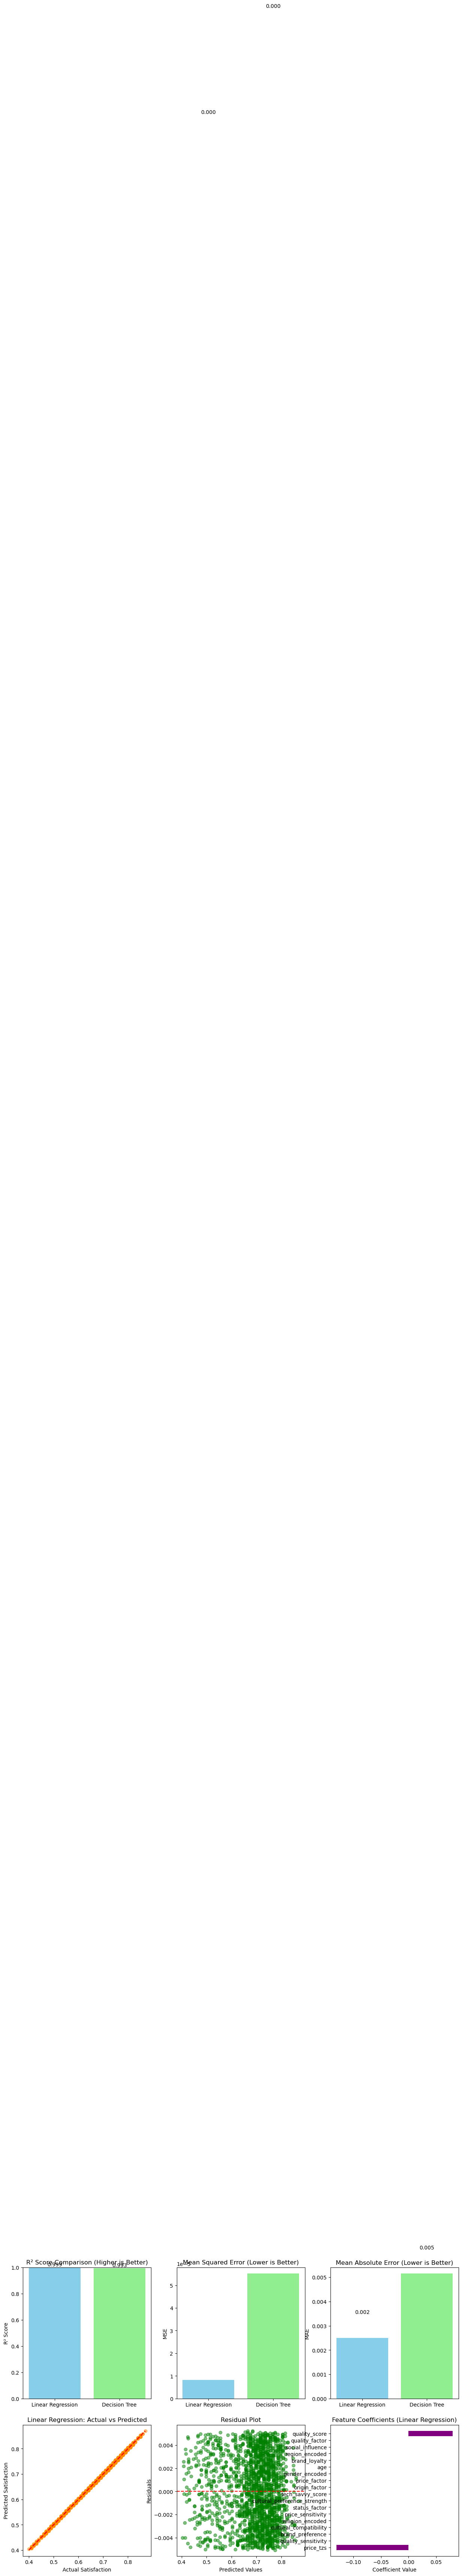

 Visualizations saved as 'model_performance_visualizations.png'


In [40]:
# %% [markdown]
# 8. Visualizations

# Figure 1: Model Performance Comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. R² Score Comparison
axes[0, 0].bar(['Linear Regression', 'Decision Tree'], 
               [lr_test_r2, dt_test_r2], 
               color=['skyblue', 'lightgreen'])
axes[0, 0].set_title('R² Score Comparison (Higher is Better)')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate([lr_test_r2, dt_test_r2]):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# 2. MSE Comparison
axes[0, 1].bar(['Linear Regression', 'Decision Tree'], 
               [lr_test_mse, dt_test_mse],
               color=['skyblue', 'lightgreen'])
axes[0, 1].set_title('Mean Squared Error (Lower is Better)')
axes[0, 1].set_ylabel('MSE')
for i, v in enumerate([lr_test_mse, dt_test_mse]):
    axes[0, 1].text(i, v + 0.001, f'{v:.3f}', ha='center')

# 3. MAE Comparison
axes[0, 2].bar(['Linear Regression', 'Decision Tree'], 
               [lr_test_mae, dt_test_mae],
               color=['skyblue', 'lightgreen'])
axes[0, 2].set_title('Mean Absolute Error (Lower is Better)')
axes[0, 2].set_ylabel('MAE')
for i, v in enumerate([lr_test_mae, dt_test_mae]):
    axes[0, 2].text(i, v + 0.001, f'{v:.3f}', ha='center')

# 4. Actual vs Predicted (Best Model)
axes[1, 0].scatter(y_test, dt_test_pred if best_model_name == "Decision Tree" else lr_test_pred, 
                   alpha=0.5, color='darkorange')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Satisfaction')
axes[1, 0].set_ylabel('Predicted Satisfaction')
axes[1, 0].set_title(f'{best_model_name}: Actual vs Predicted')

# 5. Residual Plot
residuals = y_test - (dt_test_pred if best_model_name == "Decision Tree" else lr_test_pred)
axes[1, 1].scatter(dt_test_pred if best_model_name == "Decision Tree" else lr_test_pred, 
                   residuals, alpha=0.5, color='green')
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted Values')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residual Plot')

# 6. Feature Importance (for Decision Tree)
if best_model_name == "Decision Tree":
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': dt_model.feature_importances_
    }).sort_values('importance', ascending=True)
    
    axes[1, 2].barh(feature_importance['feature'], feature_importance['importance'], color='teal')
    axes[1, 2].set_xlabel('Importance')
    axes[1, 2].set_title('Feature Importance (Decision Tree)')
else:
    # For Linear Regression, show coefficients
    coefficients = pd.DataFrame({
        'feature': X.columns,
        'coefficient': lr_model.coef_
    }).sort_values('coefficient', ascending=True)
    
    axes[1, 2].barh(coefficients['feature'], coefficients['coefficient'], color='purple')
    axes[1, 2].set_xlabel('Coefficient Value')
    axes[1, 2].set_title('Feature Coefficients (Linear Regression)')

plt.tight_layout()
plt.savefig('model_performance_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Visualizations saved as 'model_performance_visualizations.png'")

In [38]:
# %% [markdown]
# 9. Save the Best Model and Preprocessing Objects

# Save the best model
joblib.dump(best_model, 'best_model.pkl')
print(f" Best model ({best_model_name}) saved as 'best_model.pkl'")

# Save the scaler and label encoders for the app
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder_region, 'label_encoder_region.pkl')
joblib.dump(label_encoder_gender, 'label_encoder_gender.pkl')
joblib.dump(label_encoder_religion, 'label_encoder_religion.pkl')
# Save feature names
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

print(" Preprocessing objects saved:")
print("   - scaler.pkl")
print("   - label_encoder_region.pkl")
print("   - label_encoder_gender.pkl")
print("   - label_encoder_religion.pkl")
print("   - feature_names.pkl")

 Best model (Linear Regression) saved as 'best_model.pkl'
 Preprocessing objects saved:
   - scaler.pkl
   - label_encoder_region.pkl
   - label_encoder_gender.pkl
   - label_encoder_religion.pkl
   - feature_names.pkl


In [39]:
# %%
# Test the saved model
test_sample = X_test.iloc[0:1]
prediction = best_model.predict(test_sample)
print(f"\n Sample prediction test:")
print(f"Actual satisfaction: {y_test.iloc[0]:.3f}")
print(f"Predicted satisfaction: {prediction[0]:.3f}")


 Sample prediction test:
Actual satisfaction: 0.680
Predicted satisfaction: 0.681


In [56]:
# %% [markdown]
# ## 10. Summary and Conclusions

# %%
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"""
 DATASET: Tanzanian Customer Choice Dataset
   - Total records: {len(df)}
   - Features used: {len(feature_columns) + 3} (including encoded categorical)
   - Target: Customer Satisfaction (0-1 scale)
   - Source files:
     • tanzanian_customer_choice_dataset.csv (complete)
     • tanzanian_customer_choice_features.csv (feature matrix)
     • tanzanian_customer_choice_simple.csv (simple version)

 MODELS TRAINED:
   1. Linear Regression
   2. Decision Tree (max_depth=10, min_samples_split=20)

 BEST MODEL: {best_model_name}
   - Testing R² Score: {best_r2:.4f}
   - Testing MAE: {best_mae:.4f}
   - This means our model explains {best_r2*100:.1f}% of the variance in customer satisfaction

 KEY INSIGHTS:
   - The most important factors influencing customer choice are:
""")

print(f"""
 OUTPUT FILES GENERATED:
   • best_model.pkl - Trained model
   • scaler.pkl - Feature scaler
   • label_encoder_*.pkl - Encoders for categorical variables
   • feature_names.pkl - List of feature names
   • model_performance_visualizations.png - Performance plots

 All project requirements completed:
   ✓ Data preprocessing
   ✓ Linear Regression model
   ✓ Decision Tree model  
   ✓ Model evaluation and comparison
   ✓ Visualizations
   ✓ Best model saved
""")


PROJECT SUMMARY

 DATASET: Tanzanian Customer Choice Dataset
   - Total records: 10000
   - Features used: 18 (including encoded categorical)
   - Target: Customer Satisfaction (0-1 scale)
   - Source files:
     • tanzanian_customer_choice_dataset.csv (complete)
     • tanzanian_customer_choice_features.csv (feature matrix)
     • tanzanian_customer_choice_simple.csv (simple version)

 MODELS TRAINED:
   1. Linear Regression
   2. Decision Tree (max_depth=10, min_samples_split=20)

 BEST MODEL: Linear Regression
   - Testing R² Score: 0.9990
   - Testing MAE: 0.0025
   - This means our model explains 99.9% of the variance in customer satisfaction

 KEY INSIGHTS:
   - The most important factors influencing customer choice are:


 OUTPUT FILES GENERATED:
   • best_model.pkl - Trained model
   • scaler.pkl - Feature scaler
   • label_encoder_*.pkl - Encoders for categorical variables
   • feature_names.pkl - List of feature names
   • model_performance_visualizations.png - Performance p